# Chunked vs full training Neural Network

In [1]:
from colorama import Fore
from IPython.display import display, Math

from astropy.io import fits
from scipy.io import readsav
from scipy.stats import gaussian_kde
from scipy import stats as ss
import numpy as np
import pandas as pd
import os
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tools as t

## Load Data

In [2]:
# load TS1
path_data = '../data/sim_series/'  # directory where the files are saved
data_spectra = fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie0.fits')
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days, same for all time series

In [3]:
# Parameters

N = 3686  # timesteps
M = 20  # PCs
TS = 1  # time series used

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_879094/3950740032.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [4]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


## Arrange data

In [5]:
batch_size = 1
chunk_size = 21

# Chronological train/test split

train_size = int(0.7 * N)
# cut beginning and end of the arrays so all chunks have the same size
rest_train = train_size % chunk_size
rest_test  = (N - train_size) % chunk_size

X_train = X[rest_train:train_size]
y_train = y[rest_train:train_size]

X_test = X[train_size:-rest_test]
y_test = y[train_size:-rest_test]

# scale scores (X)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)

X_test_scaled = scaler.transform(X_test.numpy())
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# reshape into chunks
X_train = X_train.reshape((-1, chunk_size, M))
y_train = y_train.reshape((-1, chunk_size, 1))

X_test = X_test.reshape((-1, chunk_size, M))
y_test = y_test.reshape((-1, chunk_size, 1))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Train X shape: torch.Size([122, 21, 20])
Train y shape: torch.Size([122, 21, 1])
Test X shape: torch.Size([52, 21, 20])
Test y shape: torch.Size([52, 21, 1])


In [6]:
# DataSets and DataLoaders

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dataset = TensorDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Neural Network

In [ ]:
# model parameters
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

In [8]:
# Training
epochs = 200
model_history = {
    'y_train_true': [],
    'y_train_pred': [],
    'res_train': [],
    'loss_train': [],
}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Evaluate train set
    y_tr_true, y_tr_pred, res_tr, loss_tr = t.evaluate_model(train_loader, model, criterion)

    # Save evaluation
    model_history['y_train_true'].append(y_tr_true)
    model_history['y_train_pred'].append(y_tr_pred)
    model_history['res_train'].append(res_tr)
    model_history['loss_train'].append(loss_tr)

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}"
        )

Epoch 0: train loss = 0.9066
Epoch 20: train loss = 0.0583
Epoch 40: train loss = 0.0372
Epoch 60: train loss = 0.0313
Epoch 80: train loss = 0.0286
Epoch 100: train loss = 0.0272
Epoch 120: train loss = 0.0261
Epoch 140: train loss = 0.0254
Epoch 160: train loss = 0.0247
Epoch 180: train loss = 0.0241
Epoch 199: train loss = 0.0235


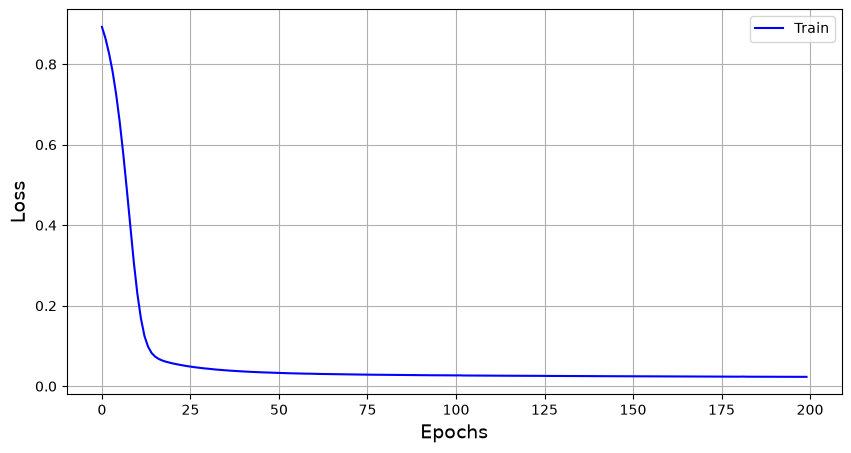

In [9]:
# plot loss history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(model_history['loss_train'], color='blue', label='Train')
#ax.plot(model_history['loss_test'], color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel('Loss', size=14)
#ax.set_yscale('log')
ax.legend()

plt.show()

In [10]:
# Evaluating the model
model.eval()

# Evaluate training set
y_train_true_nn, y_train_pred_nn, res_train_nn, loss_train_nn = t.evaluate_model(train_loader, model, criterion)

# Evaluate testing set
y_test_true_nn, y_test_pred_nn, res_test_nn, loss_test_nn = t.evaluate_model(test_loader, model, criterion)

# Print results
print('---------- NN model average loss ----------')
print(f'Train loss: {loss_train_nn:.4f}')
print(f'Test loss: {loss_test_nn:.4f}')

---------- NN model average loss ----------
Train loss: 0.0233
Test loss: 0.0343


In [11]:
X_test.shape, y_test_true_nn.shape, res_test_nn.shape, loss_test_nn

(torch.Size([52, 21, 20]), (52, 21), (52, 21), 0.03426470528714932)

In [12]:
mean_res_test_nn = np.array([np.mean(i) for i in res_test_nn])
std_res_test_nn = np.array([np.std(i) for i in res_test_nn])

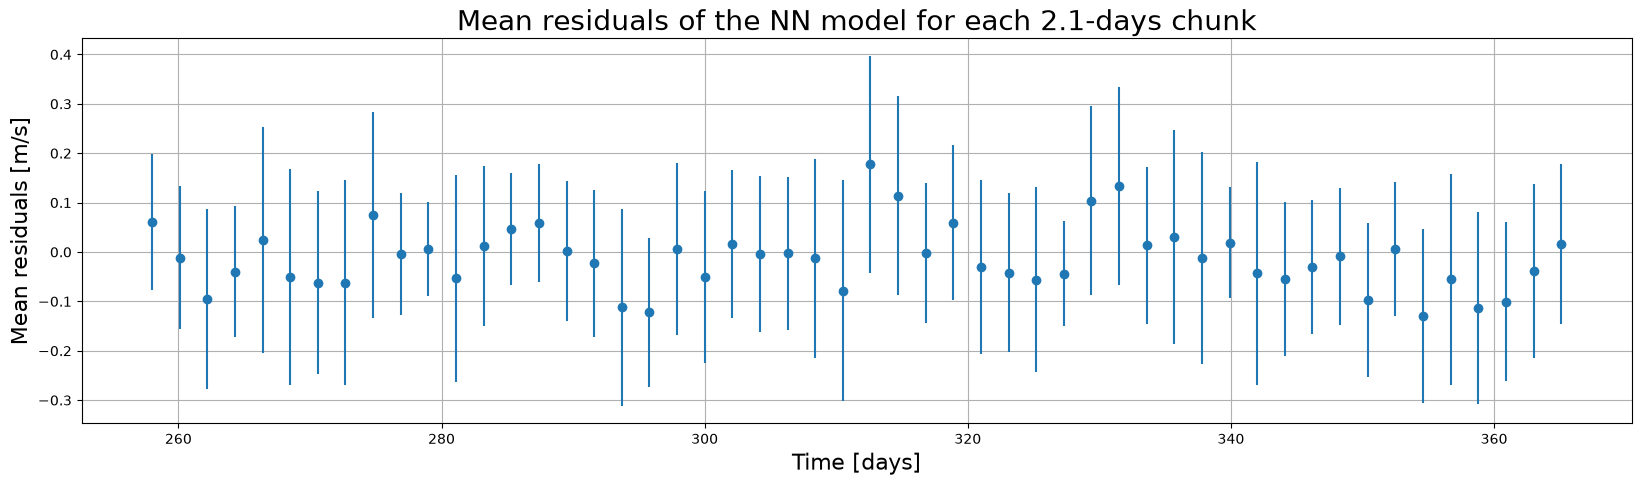

In [13]:
times_test_chunked = times[train_size:-rest_test:chunk_size]  # array of days that correspond to the time where each chunk starts

fig, ax = plt.subplots(figsize=(20, 5))
ax.grid()
ax.set_title(f'Mean residuals of the NN model for each {chunk_size / 10}-days chunk', size=20)

ax.errorbar(times_test_chunked, mean_res_test_nn, std_res_test_nn, color='C0', fmt='o')
ax.set_xlabel('Time [days]', size=16)  # time where the chunk starts
ax.set_ylabel('Mean residuals [m/s]', size=16)

plt.show()

In [14]:
# create flat arrays to ease plots
y_train_pred_nn_flat = np.concatenate(y_train_pred_nn)
y_train_true_nn_flat = np.concatenate(y_train_true_nn)
res_train_nn_flat    = np.concatenate(res_train_nn)

y_test_pred_nn_flat = np.concatenate(y_test_pred_nn)
y_test_true_nn_flat = np.concatenate(y_test_true_nn)
res_test_nn_flat    = np.concatenate(res_test_nn)

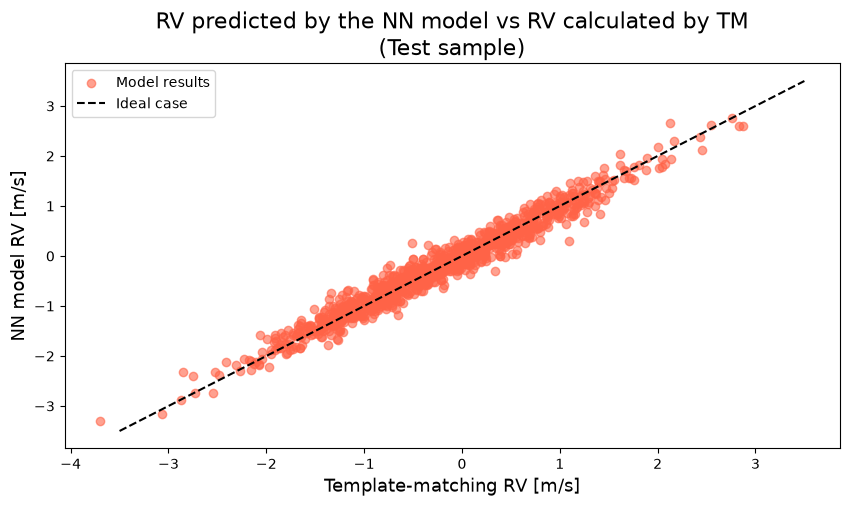

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the NN model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(y_test_true_nn_flat, y_test_pred_nn_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([-3.5, 3.5], [-3.5, 3.5], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('NN model RV [m/s]', size=13)
ax.legend()

plt.show()

In [16]:
# best model loss for each point

criterion_L1    = nn.L1Loss(reduction="none")
criterion_MSE   = nn.MSELoss(reduction="none")
criterion_Huber = nn.HuberLoss(reduction="none")

loss_L1_train = criterion_L1(torch.tensor(y_train_pred_nn), torch.tensor(y_train_true_nn))
loss_MSE_train = criterion_MSE(torch.tensor(y_train_pred_nn), torch.tensor(y_train_true_nn))
loss_Huber_train = criterion_Huber(torch.tensor(y_train_pred_nn), torch.tensor(y_train_true_nn))

loss_L1_test = criterion_L1(torch.tensor(y_test_pred_nn), torch.tensor(y_test_true_nn))
loss_MSE_test = criterion_MSE(torch.tensor(y_test_pred_nn), torch.tensor(y_test_true_nn))
loss_Huber_test = criterion_Huber(torch.tensor(y_test_pred_nn), torch.tensor(y_test_true_nn))

Standard deviation of the predicted train RVs: 0.926
Standard deviation of the train RVs: 0.942

Standard deviation of the predicted test RVs: 0.899
Standard deviation of the test RVs: 0.923



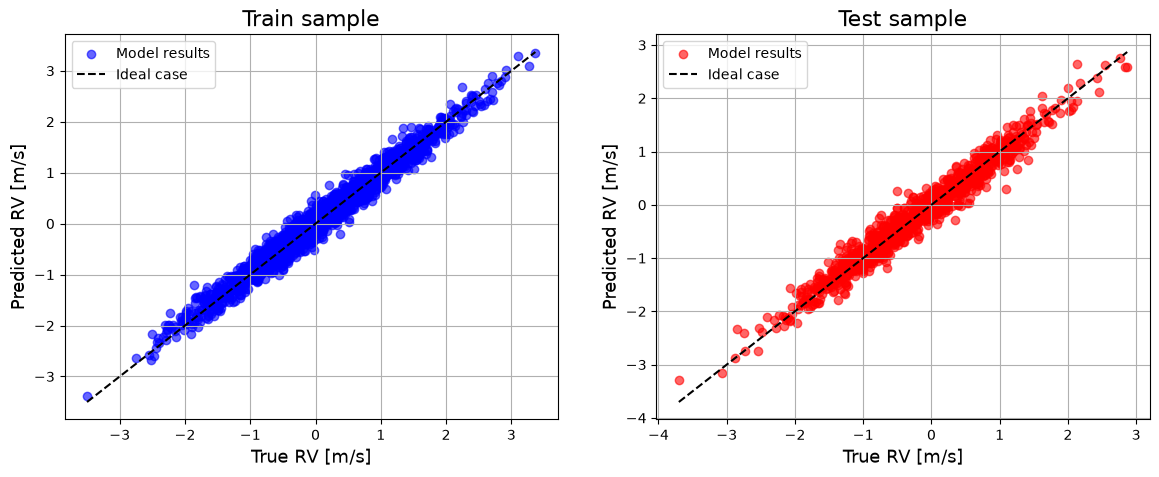

In [17]:
# plot true vs predicted for train and test samples
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

t.plot_true_vs_pred(y_train_true_nn_flat, y_train_pred_nn_flat, axs[0], 'blue')
t.plot_true_vs_pred(y_test_true_nn_flat, y_test_pred_nn_flat, axs[1], 'red')

axs[0].set_title('Train sample', size=16)
axs[1].set_title('Test sample', size=16)

print(Fore.BLUE + f'Standard deviation of the predicted train RVs: {y_train_pred_nn_flat.std():.3f}')
print(Fore.BLUE + f'Standard deviation of the train RVs: {y_train_true_nn_flat.std():.3f}\n')

print(Fore.RED + f'Standard deviation of the predicted test RVs: {y_test_pred_nn_flat.std():.3f}')
print(Fore.RED + f'Standard deviation of the test RVs: {y_test_true_nn_flat.std():.3f}\n')

In [18]:
# arange data to superpose the plots above
data_train = {
    'y_train_true': y_train_true_nn_flat,
    'y_train_pred': y_train_pred_nn_flat,
}


data_test = {
    'y_test_true': y_test_true_nn_flat,
    'y_test_pred': y_test_pred_nn_flat
}

df_train = pd.DataFrame(data=data_train)
df_test = pd.DataFrame(data=data_test)

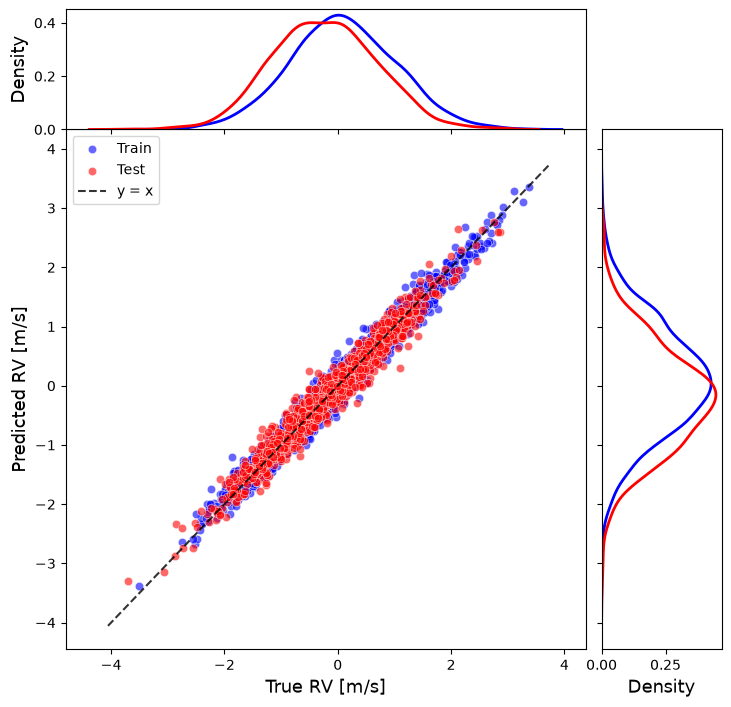

In [19]:
# Superposed with histograms

fig = plt.figure(figsize=(8, 8))

# Main scatter plot
ax = fig.add_axes([0.12, 0.12, 0.65, 0.65])

sns.scatterplot(
    data=df_train,
    x='y_train_true',
    y='y_train_pred',
    color='blue',
    alpha=.6,
    label='Train',
    ax=ax
)

sns.scatterplot(
    data=df_test,
    x='y_test_true',
    y='y_test_pred',
    color='red',
    alpha=.6,
    label='Test',
    ax=ax
)

# Reference line y = x
lims = ax.get_xlim()
ax.plot(lims, lims, '--', color='black', alpha=0.8, label='y = x')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.legend()


# ---- Smooth marginal distributions ----

# Top: distributions of TRUE values
ax_top = fig.add_axes([0.12, 0.77, 0.65, 0.15], sharex=ax)

sns.kdeplot(
    data=df_train,
    x='y_train_true',
    color='blue',
    linewidth=2,
    ax=ax_top,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    x='y_test_true',
    color='red',
    linewidth=2,
    ax=ax_top,
    label='Test'
)

ax_top.set_ylabel('Density', size=13)
ax_top.set_xlabel('')
ax_top.tick_params(axis='x', labelbottom=False)


# Right: distributions of PREDICTED values
ax_right = fig.add_axes([0.79, 0.12, 0.15, 0.65], sharey=ax)

sns.kdeplot(
    data=df_train,
    y='y_train_pred',
    color='blue',
    linewidth=2,
    ax=ax_right,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    y='y_test_pred',
    color='red',
    linewidth=2,
    ax=ax_right,
    label='Test'
)

ax_right.set_xlabel('Density', size=13)
ax_right.set_ylabel('')
ax_right.tick_params(axis='y', labelleft=False)

plt.show()

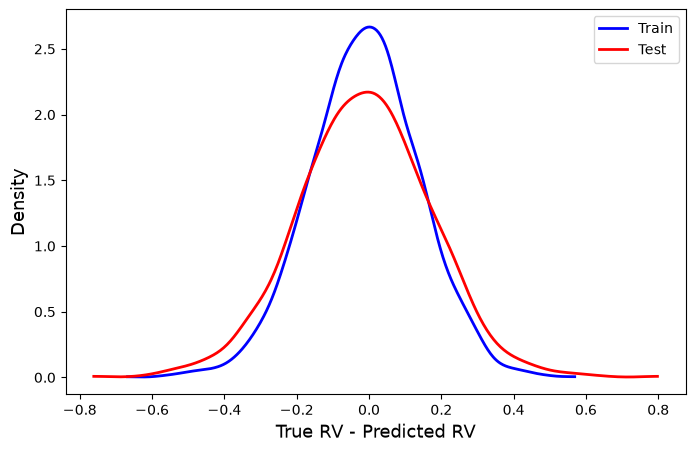

In [20]:
# compare train and test residuals
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(res_train, alpha=.5, density=True)
#ax.hist(res_val, alpha=.5, density=True)
#ax.hist(res_test, alpha=.5, density=True)

# Smooth KDE curve
# gaussian_kde: estimates the probability density function of a random variable
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde_train = gaussian_kde(res_train_nn_flat)
x_train = np.linspace(res_train_nn_flat.min(), res_train_nn_flat.max(), 500)

kde_test = gaussian_kde(res_test_nn_flat)
x_test = np.linspace(res_test_nn_flat.min(), res_test_nn_flat.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()

In [21]:
# compute means
mean_train = np.mean(res_train_nn_flat)
mean_test = np.mean(res_test_nn_flat)

# compute stds
std_train = np.std(res_train_nn_flat)
std_test = np.std(res_test_nn_flat)

In [22]:
print('---------- Mean of RV residuals ----------')
print(f'Train: {mean_train:.5f}')
print(f'Test: {mean_test:.5f}')

print('---------- Std of RV residuals ----------')
print(f'Train: {std_train:.4f}')
print(f'Test: {std_test:.4f}')

---------- Mean of RV residuals ----------
Train: -0.01172
Test: -0.01267
---------- Std of RV residuals ----------
Train: 0.1521
Test: 0.1847


In [23]:
# calculate std of the residuals (variable sigma) for each epoch

sigma_train = np.array(model_history['res_train'])
#sigma_test = np.array(model_history['y_test_true']) - np.array(model_history['y_test_pred'])

sigma_train = sigma_train.reshape(sigma_train.shape[0], -1)

sigma_train = np.std(sigma_train, axis=1)
#sigma_test = np.std(sigma_test, axis=1)

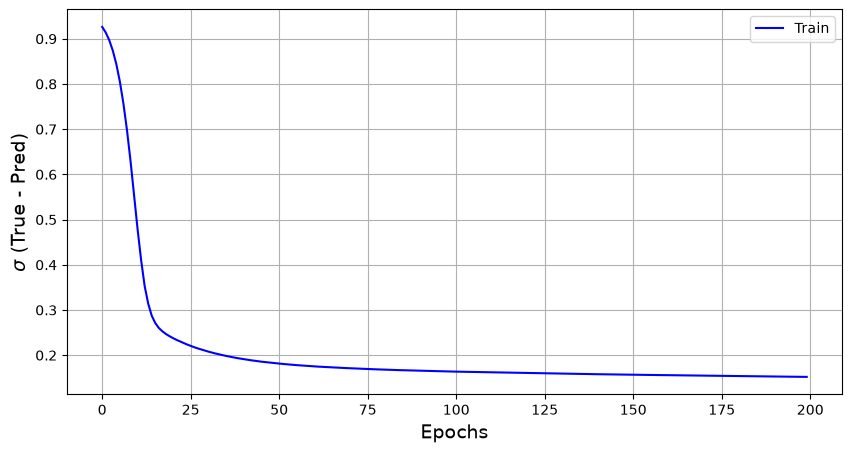

In [24]:
# plot sigma history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(sigma_train, color='blue', label='Train')
#ax.plot(sigma_test, color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel(r'$\sigma$ (True - Pred)', size=14)
ax.legend()
#ax.set_yscale('log')

plt.show()

In [25]:
# are PCs correlated with the residuals? (NN model)
scores_matrix = np.array(X)  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components

res_all = np.concatenate((res_train_nn_flat, res_test_nn_flat))
corr_all = []

for i in range(M):
    scores_i = scores_matrix[rest_train:-rest_test, i]
    corr = ss.pearsonr(res_all, scores_i)[0]
    corr_all.append(corr)

/tmp/ipykernel_879094/708887179.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_matrix = np.array(X)  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components


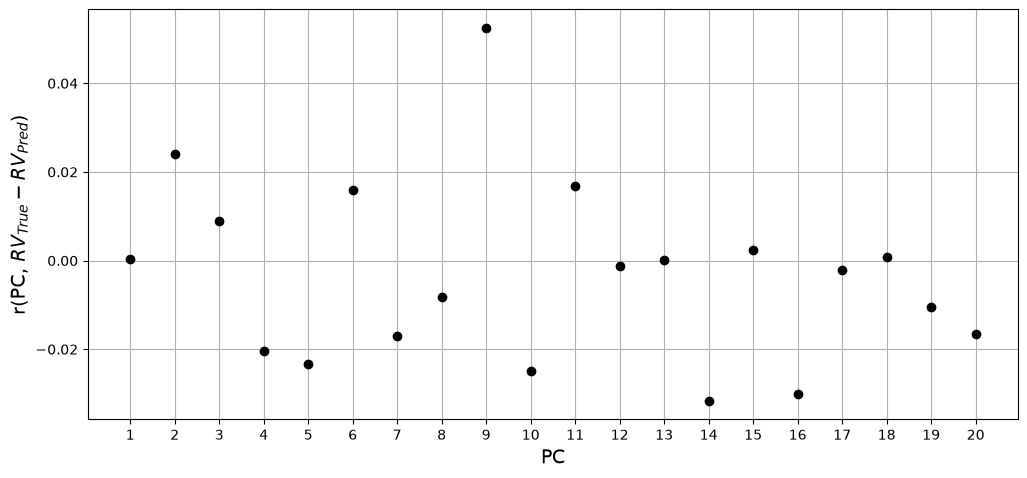

In [26]:
pc_arr = np.linspace(1, M, M)

fig, ax = plt.subplots(figsize=(12, 5))
ax.grid()

ax.scatter(pc_arr, corr_all, color='k', zorder=2)
ax.set_xlabel('PC', size=14)
ax.set_xticks(pc_arr)
ax.set_ylabel(r'r(PC, $RV_{True} - RV_{Pred}$)', size=14)

plt.subplots_adjust(top=.93)
plt.show()

## Neural Network without chunks

In [27]:
batch_size_full = 10  # takes 10 mins for batch_size = 1 and 200 epochs, but loss decays faster than for the chunked NN

# keep the cut at beginning and end of the arrays, so the samples compared are the same for all techniques
# reshape taking out the chunks
X_train_full = X_train.reshape((-1, M))
y_train_full = y_train.reshape((-1, 1))

X_test_full = X_test.reshape((-1, M))
y_test_full = y_test.reshape((-1, 1))

print("Train X shape:", X_train_full.shape)
print("Train y shape:", y_train_full.shape)

print("Test X shape:", X_test_full.shape)
print("Test y shape:", y_test_full.shape)

Train X shape: torch.Size([2562, 20])
Train y shape: torch.Size([2562, 1])
Test X shape: torch.Size([1092, 20])
Test y shape: torch.Size([1092, 1])


In [28]:
# DataSets and DataLoaders

train_dataset_full = TensorDataset(X_train_full, y_train_full)

train_loader_full = DataLoader(
    train_dataset_full,
    batch_size=batch_size_full,
    shuffle=True
)

test_dataset_full = TensorDataset(X_test_full, y_test_full)

test_loader_full = DataLoader(
    test_dataset_full,
    batch_size=batch_size_full,
    shuffle=False
)

In [29]:
# model parameters
# M = 20 PCs
# added _full to the names to avoid conflicts with the chunked NN

model_full = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

# Loss and optimizer
criterion_full = nn.MSELoss()
optimizer_full = torch.optim.AdamW(
    model_full.parameters(),
    lr=1e-4,
    weight_decay=0
)

In [30]:
# Training
# same epochs as chunked NN
model_history_full = {
    'y_train_true': [],
    'y_train_pred': [],
    'res_train': [],
    'loss_train': [],
}

for epoch in range(epochs):
    model_full.train()
    train_loss = 0.0  # variable used only in this loop, does not need a change of name
    for X_batch, y_batch in train_loader_full:  # X_batch and y_batch only used in the loop

        # Forward pass
        y_pred = model_full(X_batch)  # y_pred is temporal

        # Calculate loss
        loss = criterion_full(y_pred, y_batch)  # loss is temporal

        # Backpropagation
        optimizer_full.zero_grad()
        loss.backward()
        optimizer_full.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader_full)  # train_loss is temporal

    # Evaluate train set
    y_tr_true, y_tr_pred, res_tr, loss_tr = t.evaluate_model(train_loader_full, model_full, criterion_full)  # results are temporal

    # Save evaluation
    model_history_full['y_train_true'].append(y_tr_true)
    model_history_full['y_train_pred'].append(y_tr_pred)
    model_history_full['res_train'].append(res_tr)
    model_history_full['loss_train'].append(loss_tr)

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}"
        )

Epoch 0: train loss = 0.8536
Epoch 20: train loss = 0.0349
Epoch 40: train loss = 0.0283
Epoch 60: train loss = 0.0257
Epoch 80: train loss = 0.0243
Epoch 100: train loss = 0.0234
Epoch 120: train loss = 0.0227
Epoch 140: train loss = 0.0217
Epoch 160: train loss = 0.0213
Epoch 180: train loss = 0.0209
Epoch 199: train loss = 0.0202


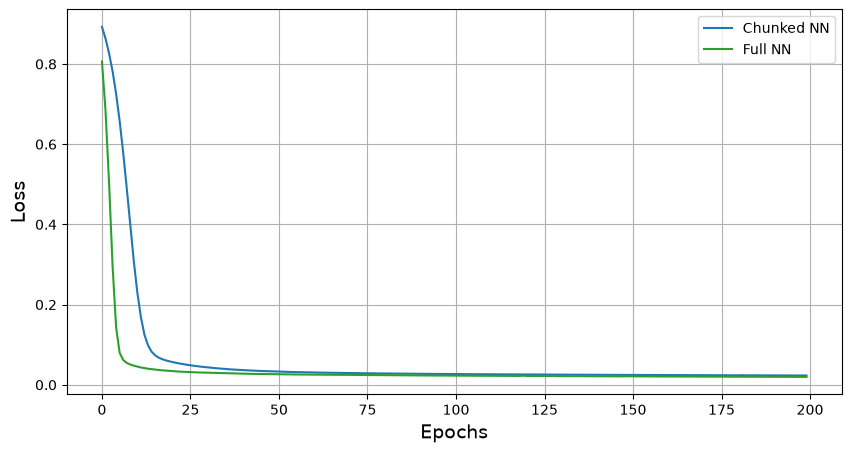

In [31]:
# plot loss history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(model_history['loss_train'], color='C0', label='Chunked NN')
ax.plot(model_history_full['loss_train'], color='C2', label='Full NN')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel('Loss', size=14)
#ax.set_yscale('log')
ax.legend()

plt.show()

In [32]:
# Evaluating the model
model_full.eval()

# Evaluate training set
y_train_true_nn_full, y_train_pred_nn_full, res_train_nn_full, loss_train_nn_full = t.evaluate_model(train_loader_full, model_full, criterion_full)

# Evaluate testing set
y_test_true_nn_full, y_test_pred_nn_full, res_test_nn_full, loss_test_nn_full = t.evaluate_model(test_loader_full, model_full, criterion_full)

# Print results
print('---------- Full NN model average loss ----------')
print(f'Train loss: {loss_train_nn_full:.4f}')
print(f'Test loss: {loss_test_nn_full:.4f}')

---------- Full NN model average loss ----------
Train loss: 0.0198
Test loss: 0.0386


In [33]:
# reshape residuals into chunks to compare errorbar plots
res_test_nn_full_chunked = res_test_nn_full.reshape((-1, chunk_size))

# calculate mean and std per chunk
mean_res_test_nn_full_chunked = np.array([np.mean(i) for i in res_test_nn_full_chunked])
std_res_test_nn_full_chunked = np.array([np.std(i) for i in res_test_nn_full_chunked])

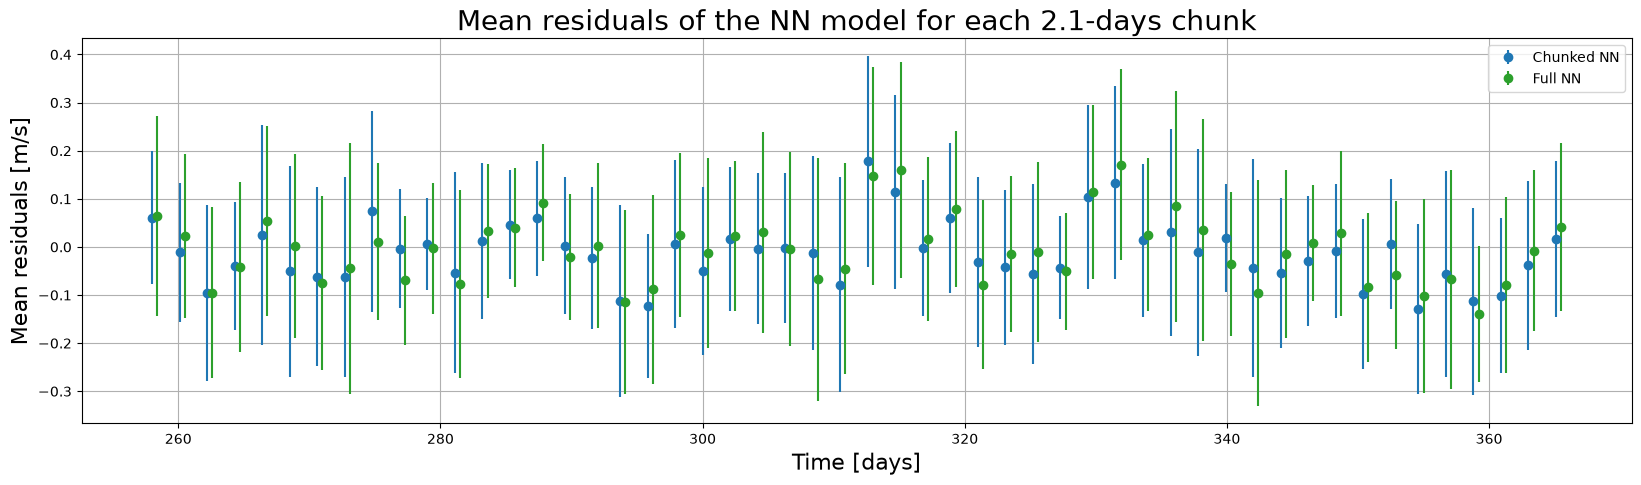

In [34]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.grid()
ax.set_title(f'Mean residuals of the NN model for each {chunk_size / 10}-days chunk', size=20)

ax.errorbar(times_test_chunked, mean_res_test_nn, std_res_test_nn, color='C0', fmt='o', label='Chunked NN')
ax.errorbar(times_test_chunked+.4, mean_res_test_nn_full_chunked, std_res_test_nn_full_chunked, color='C2', fmt='o', label='Full NN')
ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Mean residuals [m/s]', size=16)
ax.legend()

plt.show()

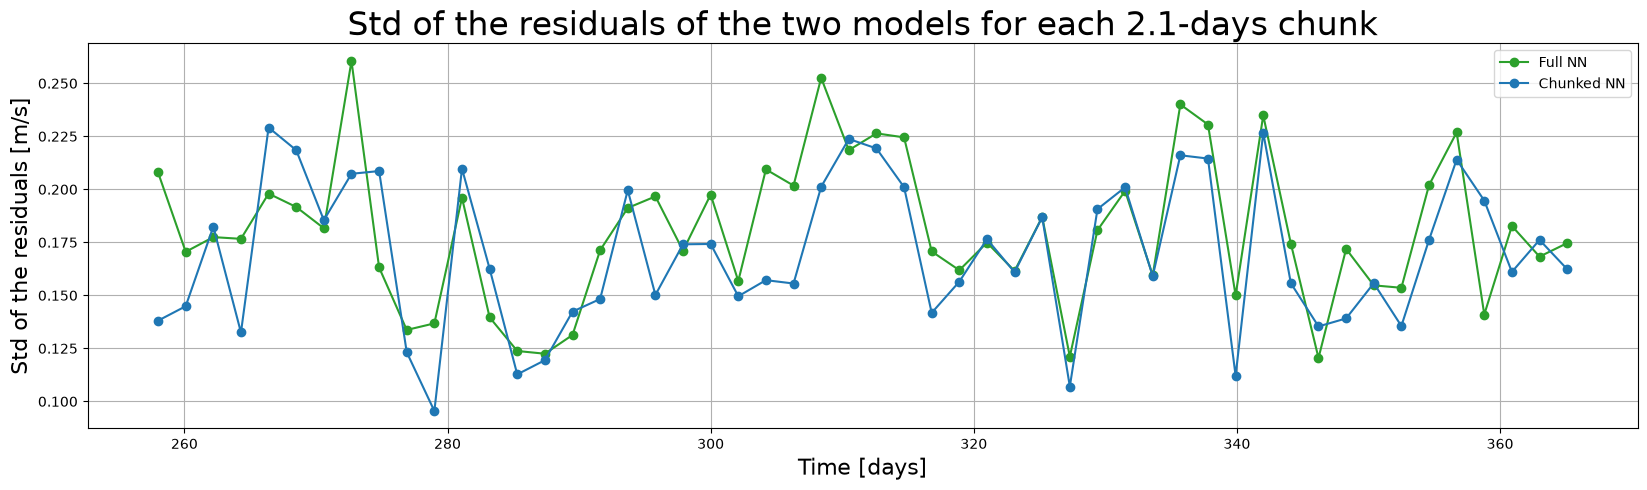

In [35]:
# comparing std of the residuals

fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'Std of the residuals of the two models for each {chunk_size / 10}-days chunk', size=24)

ax.grid()
ax.plot(times_test_chunked, std_res_test_nn_full_chunked, marker='o', label='Full NN', color='C2')
ax.plot(times_test_chunked, std_res_test_nn, marker='o', label='Chunked NN', color='C0')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Std of the residuals [m/s]', size=16)
ax.legend()

plt.show()

In [36]:
# How many of the orange points are above the blue ones?
std_count = sum(std_res_test_nn_full_chunked < std_res_test_nn)
chunks = len(std_res_test_nn_full_chunked)
print('The full NN model has a standard deviation higher than the chunked NN model in '
      f'{std_count} out of the {chunks} chunks.\n'
      f'That is {std_count / chunks * 100:.0f}% of the cases.')

The full NN model has a standard deviation higher than the chunked NN model in 18 out of the 52 chunks.
That is 35% of the cases.


## Linear model

In [37]:
# do a linear model (y = I * X) to compare with the result from the neural network
k = 20  # number of PCs used for the fit
scores_matrix = np.array(X)[:, :k]  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components

# separate the scores and RVs into sub samples
scores_train = scores_matrix[rest_train:train_size]
scores_test  = scores_matrix[train_size:-rest_test]

y_true_linear_flat       = np.squeeze(np.array(y))  # RV data in a 1-d array
y_train_true_linear_flat = y_true_linear_flat[rest_train:train_size]
y_test_true_linear_flat  = y_true_linear_flat[train_size:-rest_test]

# training the linear model using all the scores

G = np.dot(scores_train.T, scores_train)
b = np.dot(scores_train.T, y_train_true_linear_flat)
alpha = np.linalg.solve(G, b)

/tmp/ipykernel_879094/2076101157.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_matrix = np.array(X)[:, :k]  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components
/tmp/ipykernel_879094/2076101157.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true_linear_flat       = np.squeeze(np.array(y))  # RV data in a 1-d array


In [38]:
# train the linear model by chunks
arr_alpha = []  # array of alphas from each chunk (theoretically, all alphas should be the same)
i = 0

while i < len(y_train_true_linear_flat):
    scores_i = scores_train[i:i+chunk_size]
    rv_true = y_train_true_linear_flat[i:i+chunk_size]

    G_i = np.dot(scores_i.T, scores_i)
    b_i = np.dot(scores_i.T, rv_true)
    alpha_i = np.linalg.solve(G, b)
    arr_alpha.append(alpha_i)

    i += chunk_size

arr_alpha = np.array(arr_alpha)

# sanity check: are all alpha_i (from the loop) the same?
print('Sanity check: Are all alpha_i the same?')
print((arr_alpha[0] == arr_alpha).all())

# does this give the same results as using the whole training sample at once?
print('\nDoes this give the same results as using the whole training sample at once?')
print((alpha == arr_alpha[0]).all())

Sanity check: Are all alpha_i the same?
True

Does this give the same results as using the whole training sample at once?
True


In [39]:
# use alpha to predict the RVs in chunks of 21 points from the test sample
y_test_pred_linear = []
res_test_linear = []
i = 0
#chunk_size = 21  # already defined for the NN predictions

while i < len(y_test_true_linear_flat):  # true RVs are always the same
    scores_i = scores_test[i:i+chunk_size]
    rv_true = y_test_true_linear_flat[i:i+chunk_size]

    pred = np.dot(alpha, scores_i.T)
    y_test_pred_linear.append(pred)
    res_test_linear.append(rv_true - pred)
    i += chunk_size

print(f'{len(y_test_pred_linear)} chunks of {chunk_size} points.')

52 chunks of 21 points.


In [40]:
# mean and std of the residuals of each chunk
mean_res_test_linear = np.array([np.mean(i) for i in res_test_linear])
std_res_test_linear = np.array([np.std(i) for i in res_test_linear])

## Linear vs NN

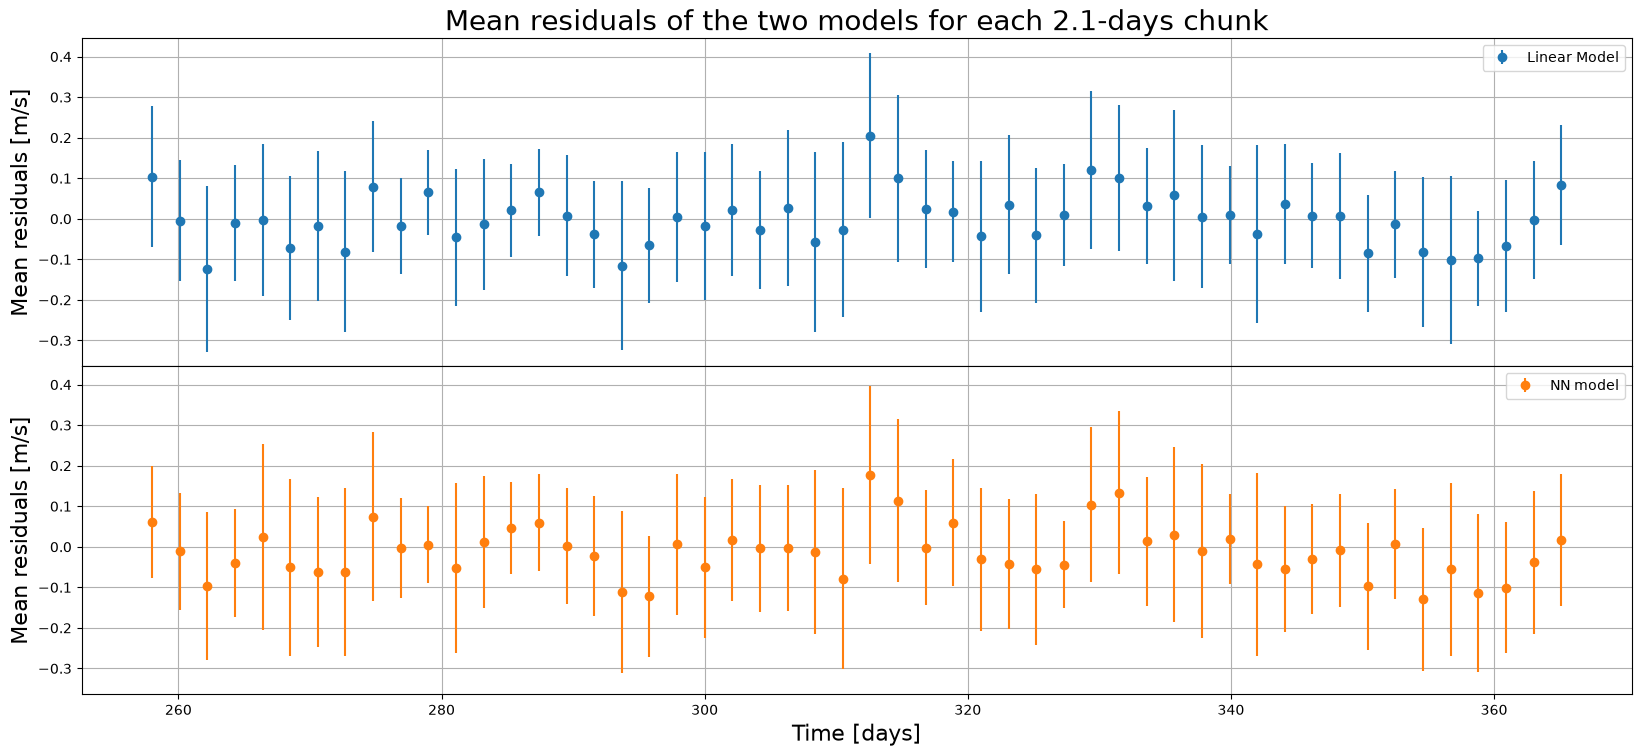

In [41]:
#chunk_array = (np.linspace(1, len(y_test_linear), len(y_test_linear)) * chunk_size + train_size) * 144 / 60 / 24  # array of days corresponding to the test sample

fig, axs = plt.subplots(2, 1, figsize=(20, 8), sharex=True, sharey=True)
axs[0].set_title(f'Mean residuals of the two models for each {chunk_size / 10}-days chunk', size=20)

axs[0].grid()
axs[0].errorbar(times_test_chunked, mean_res_test_linear, std_res_test_linear, color='C0', fmt='o', label='Linear Model')
axs[0].set_ylabel('Mean residuals [m/s]', size=16)
axs[0].legend()

axs[1].grid()
axs[1].errorbar(times_test_chunked, mean_res_test_nn, std_res_test_nn, color='C1', fmt='o', label='NN model')
axs[1].set_xlabel('Time [days]', size=16)
axs[1].set_ylabel('Mean residuals [m/s]', size=16)
axs[1].legend()

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

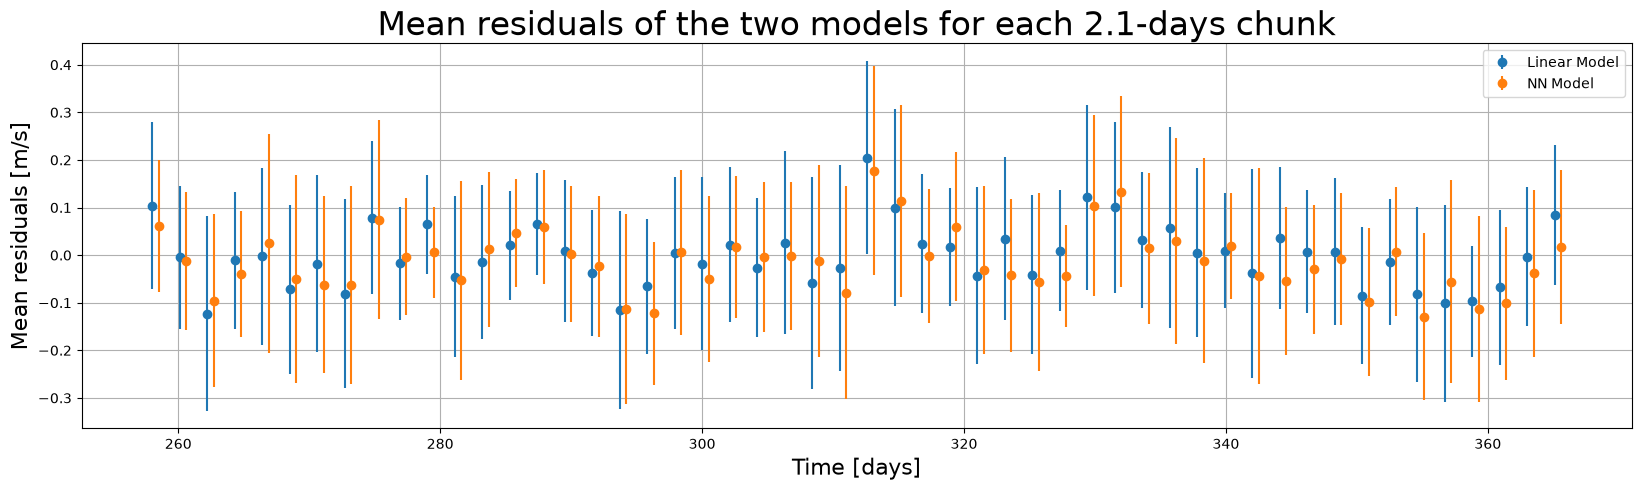

In [42]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'Mean residuals of the two models for each {chunk_size / 10}-days chunk', size=24)

ax.grid()
ax.errorbar(times_test_chunked, mean_res_test_linear, std_res_test_linear, fmt='o', label='Linear Model')
ax.errorbar(times_test_chunked+.5, mean_res_test_nn, std_res_test_nn, fmt='o', label='NN Model')
#ax.errorbar(times_test_chunked+1, mean_res_test_nn_full_chunked, std_res_test_nn_full_chunked, fmt='o', label='Full NN')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Mean residuals [m/s]', size=16)
ax.legend()

plt.show()

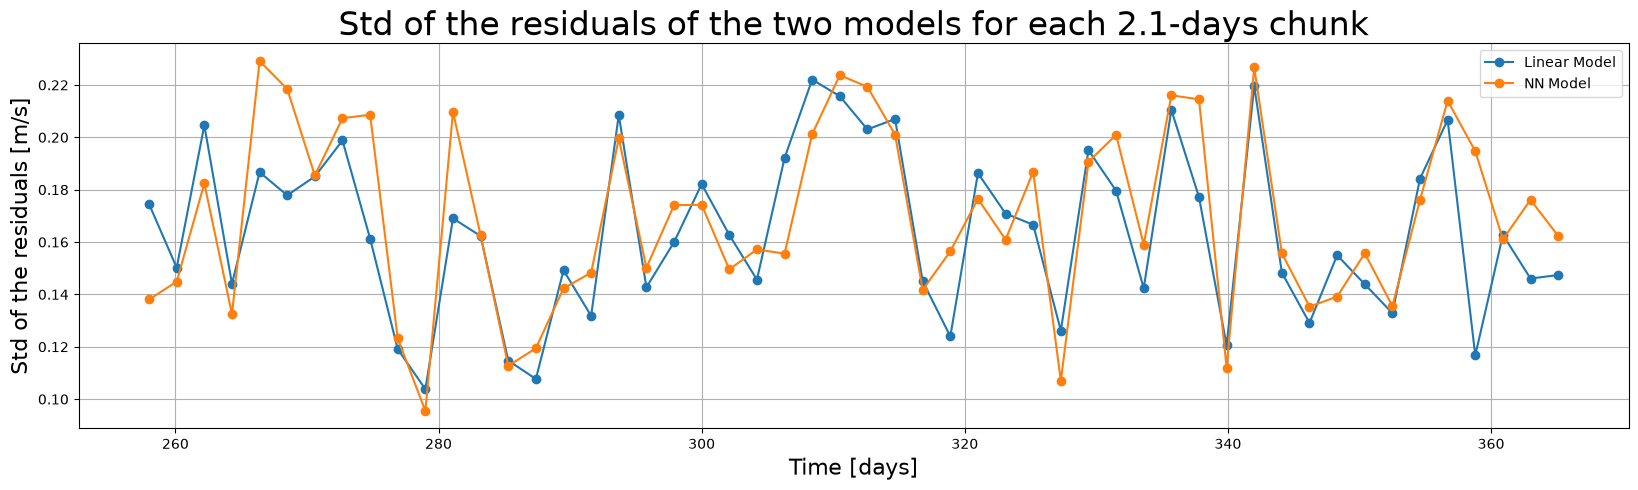

In [43]:
# comparing std of the residuals

fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'Std of the residuals of the two models for each {chunk_size / 10}-days chunk', size=24)

ax.grid()
ax.plot(times_test_chunked, std_res_test_linear, marker='o', label='Linear Model')
ax.plot(times_test_chunked, std_res_test_nn, marker='o', label='NN Model')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Std of the residuals [m/s]', size=16)
ax.legend()

plt.show()

In [44]:
# How many of the orange points are above the blue ones?
std_count = sum(std_res_test_linear < std_res_test_nn)
chunks = len(std_res_test_linear)
print('The NN model has a standard deviation higher than the linear model in '
      f'{std_count} out of the {chunks} chunks.\n'
      f'That is {std_count / chunks * 100:.0f}% of the cases.')

The NN model has a standard deviation higher than the linear model in 30 out of the 52 chunks.
That is 58% of the cases.


In [45]:
# flatten predictions and calculate residuals
y_test_pred_linear_flat = np.concatenate(y_test_pred_linear)
res_test_linear = y_test_true_linear_flat - y_test_pred_linear_flat

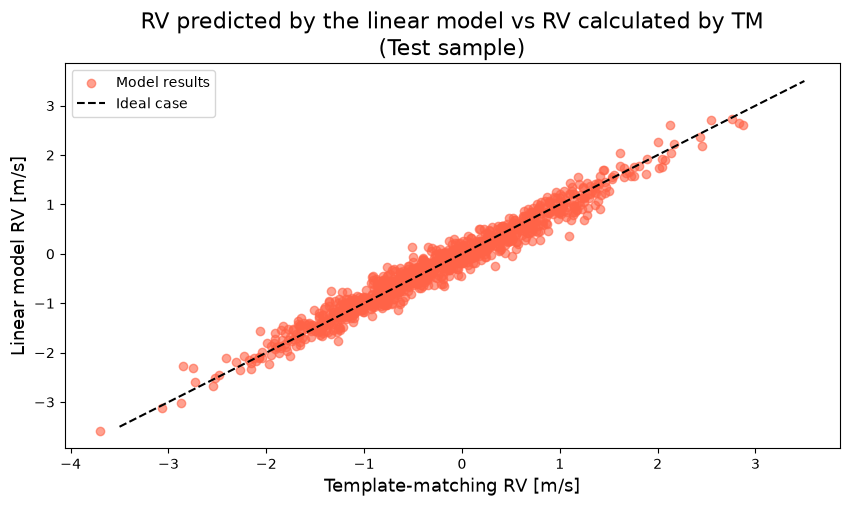

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the linear model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(y_test_true_nn_flat, y_test_pred_linear_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([-3.5, 3.5], [-3.5, 3.5], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('Linear model RV [m/s]', size=13)
ax.legend()

plt.show()

In [47]:
times_test = times[train_size:-rest_test]

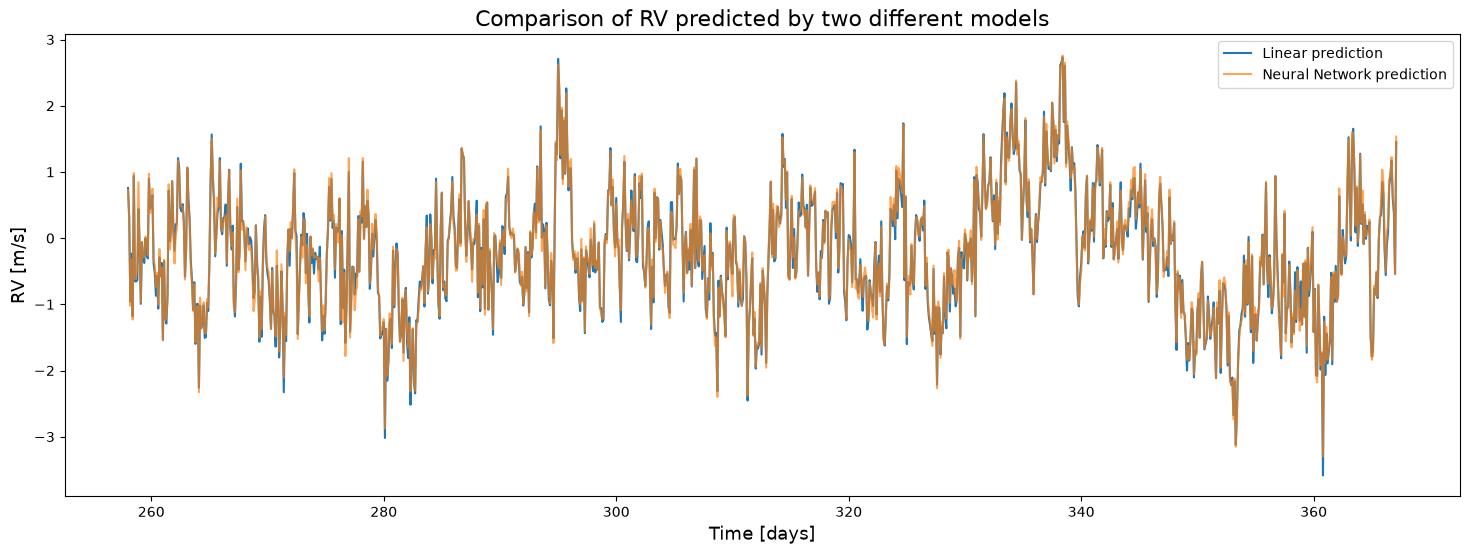

In [48]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_title('Comparison of RV predicted by two different models', size=16)

ax.plot(times_test, y_test_pred_linear_flat, label='Linear prediction')
ax.plot(times_test, y_test_pred_nn_flat, label='Neural Network prediction', alpha=.7)
#plt.plot(times_test, rv[train_size + val_size:])

ax.set_xlabel('Time [days]', size=13)
ax.set_ylabel('RV [m/s]', size=13)
ax.legend()

plt.show()

In [49]:
# compare mean and std of the residuals
print('---------- Mean residuals of the predicted RVs ----------')
print(f'Linear model: {np.mean(res_test_linear):.3f} m/s')
print(f'Neural Network model: {np.mean(res_test_nn):.3f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.mean(y_test_pred_linear_flat - np.array(y_test_pred_nn_flat)):.3f} m/s')

print('---------- Standard deviation of the residuals of the predicted RVs ----------')
print(f'Linear prediction: {np.std(res_test_linear):.2f} m/s')
print(f'Neural Network: {np.std(res_test_nn):.2f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.std(y_test_pred_linear_flat - np.array(y_test_pred_nn_flat)):.2f} m/s')

---------- Mean residuals of the predicted RVs ----------
Linear model: -0.001 m/s
Neural Network model: -0.013 m/s
Linear prediction - Neural Network prediction = -0.011 m/s
---------- Standard deviation of the residuals of the predicted RVs ----------
Linear prediction: 0.18 m/s
Neural Network: 0.18 m/s
Linear prediction - Neural Network prediction = 0.09 m/s


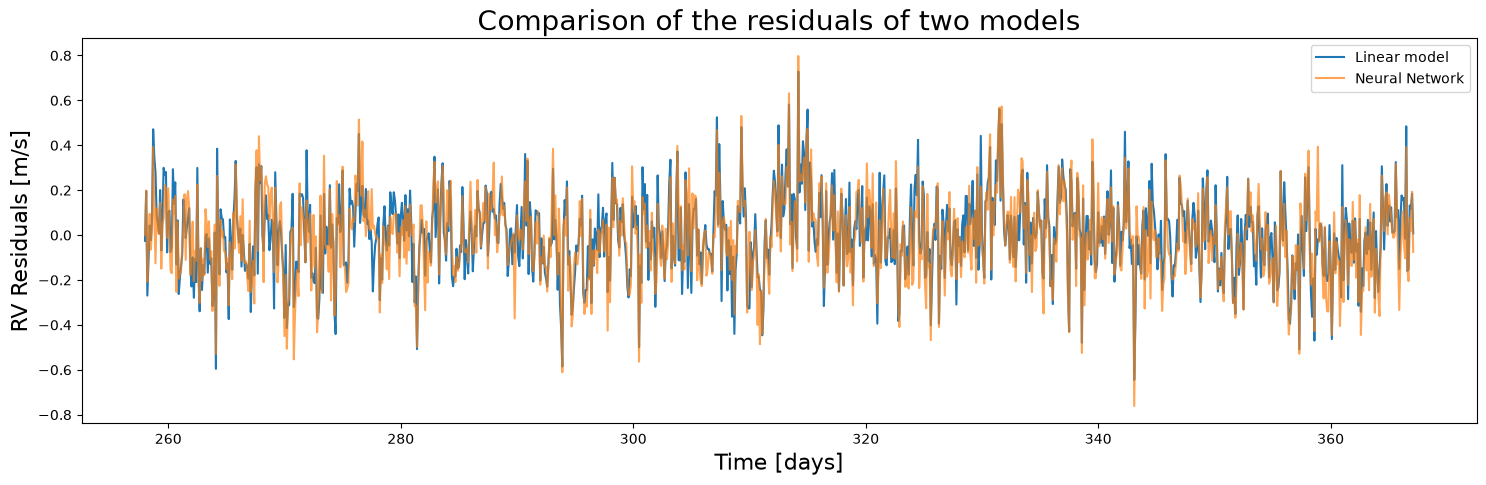

In [50]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Comparison of the residuals of two models', size=20)

ax.plot(times_test, res_test_linear, label='Linear model')
ax.plot(times_test, res_test_nn_flat, label='Neural Network', alpha=.7)

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

In [51]:
# calculate module of the residuals for the two models
print(f'Module of the residuals of the NN model:     {np.linalg.norm(res_test_nn):.1f} m/s')
print(f'Module of the residuals of the linear model: {np.linalg.norm(res_test_linear):.1f} m/s')

Module of the residuals of the NN model:     6.1 m/s
Module of the residuals of the linear model: 5.9 m/s


In [52]:
# calculate module of the residuals in each chunk (then avg and std) for the two models
mod_res_nn = np.array([np.linalg.norm(i) for i in y_test_pred_nn])
avg_mod_nn = np.mean(mod_res_nn)
std_mod_nn = np.std(mod_res_nn)

mod_res_linear = np.array([np.linalg.norm(i) for i in y_test_pred_linear])
avg_mod_linear = np.mean(mod_res_linear)
std_mod_linear = np.std(mod_res_linear)

print('Average +- std of the MODULE of the residuals from the chunks:')
print(f'Module of the residuals of the NN model:     {avg_mod_nn:.2f} +- {std_mod_nn:.2f} m/s')
print(f'Module of the residuals of the linear model: {avg_mod_linear:.2f} +- {std_mod_linear:.2f} m/s')

Average +- std of the MODULE of the residuals from the chunks:
Module of the residuals of the NN model:     4.00 +- 1.41 m/s
Module of the residuals of the linear model: 4.01 +- 1.43 m/s


This was done by calculating the module of each chunk. That gives a vector of size N_chunks for each of the models. Then, calculate the avg and std for each of the two vectors, in order to compare.